# Case Study: CNN Image Classification with Transfer Learning



In [3]:
# ---- Part 0: Environment Setup ----
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow opencv-python

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

print(tf.__version__)


2.20.0


In [4]:
# GPU check
print("GPUs:", tf.config.list_physical_devices('GPU'))


GPUs: []


# Part 1: Data Exploration & Preprocessing

### This section:

1. Loads CIFAR-10 (tfds or `keras.datasets.cifar10`) and preview shapes.  
2. Visualizes a small grid of samples by class; show class distribution.  
3. Implements augmentation strategies (e.g., flips/rotations; optional cutout/mixup).  
4. Analyzes pixel intensity distributions and choose normalization strategy.  
5. Creates train/val split with balanced classes and a tf.data pipeline.


In [5]:
from tensorflow.keras.datasets import cifar10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()
print(X_train_full.shape, X_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a validation split from train

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=SEED)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1737s 10us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


In [6]:
#Shape
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

#Training images and labels have different lengths
assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_test.shape[0] == y_test.shape[0]

#Training images contain NaN values
assert not np.isnan(X_train).any() and not np.isnan(y_train).any()
assert not np.isnan(X_val).any() and not np.isnan(y_val).any()
assert not np.isnan(X_test).any() and not np.isnan(y_test).any()
assert set(np.unique(y_train)) == set(range(10))

(45000, 32, 32, 3) (45000,)
(5000, 32, 32, 3) (5000,)
(10000, 32, 32, 3) (10000,)


In [7]:
print("Raw minimum:", X_train.min())
print("Raw maximum:", X_train.max())
print("Raw mean:", X_train.mean())
print("Raw standard deviation:", X_train.std())

Raw minimum: 0
Raw maximum: 255
Raw mean: 120.67428969907408
Raw standard deviation: 64.13232319585192


In [8]:
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

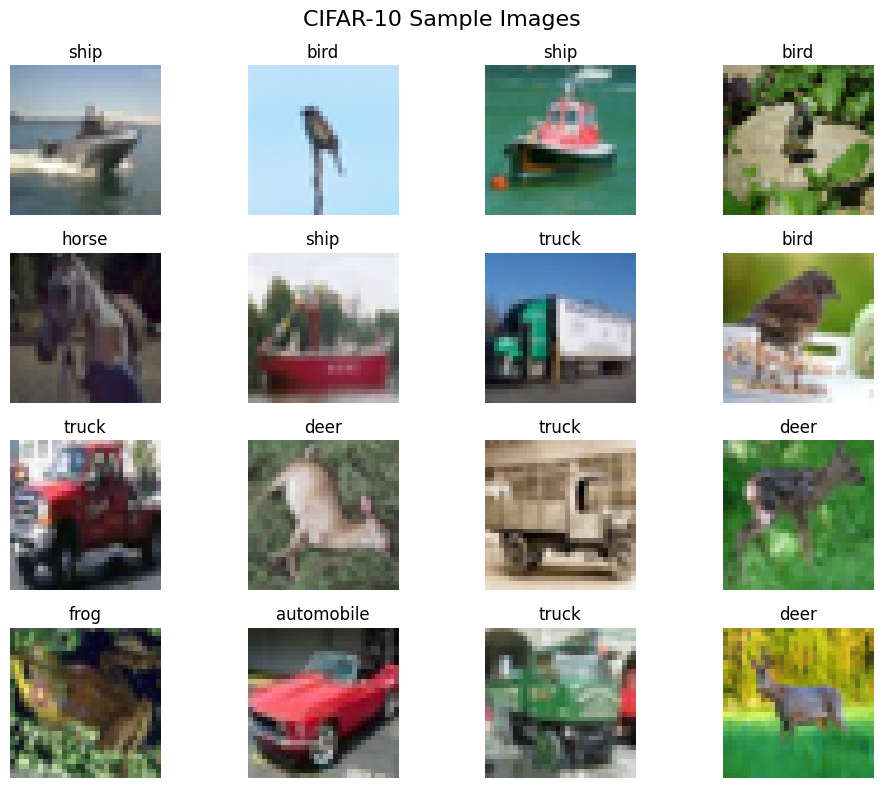

Pixel value range: 0.0 to 1.0
Mean pixel value: 0.47
Standard deviation: 0.25


In [9]:
plt.figure(figsize=(10, 8))
idxs = np.random.choice(len(X_train), size=16, replace=False)

for j, idx in enumerate(idxs):
    plt.subplot(4, 4, j + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[y_train[idx]])
    plt.axis("off")

plt.suptitle("CIFAR-10 Sample Images", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"Mean pixel value: {X_train.mean():.2f}")
print(f"Standard deviation: {X_train.std():.2f}")

In [10]:
# ---- Augmentation shells ----
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)])

In [11]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

In [12]:
BATCH_SIZE = 32

train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=len(X_train),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Part 2: Custom CNN Architecture Design

### This section:
1. Builds a baseline CNN (conv blocks + pooling).  
2. Adds techniques: BatchNorm, Dropout, optional residual connections.  
3. Explores kernel sizes, pooling, and activations; compare small variants.  
4. Optimizes the architecture for CIFAR-10; keeps parameter count reasonable.


In [16]:
# ---- Custom CNN baseline scaffold ----
def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x=layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)
    x=layers.MaxPooling2D(pool_size=2)(x)
    x=layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
    x=layers.MaxPooling2D(pool_size=2)(x)
    x=layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
    x=layers.MaxPooling2D(pool_size=2)(x)

    x=layers.Flatten()(x)

    x=layers.Dense(128, activation='relu')(x)
    x=layers.Dropout(0.5)(x)
    x=layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name="custom_cnn")
    return model


In [17]:
model1=build_custom_cnn()
model1.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,818 (655.54 KB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model1=build_custom_cnn(input_shape=(32,32,3), num_classes=10)
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=40, verbose=1)

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3548 - loss: 1.7294 - val_accuracy: 0.4964 - val_loss: 1.3606
Epoch 2/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4856 - loss: 1.4183 - val_accuracy: 0.5702 - val_loss: 1.1932
Epoch 3/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5356 - loss: 1.3069 - val_accuracy: 0.5992 - val_loss: 1.1231
Epoch 4/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5702 - loss: 1.2206 - val_accuracy: 0.6184 - val_loss: 1.0688
Epoch 5/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5924 - loss: 1.1621 - val_accuracy: 0.6510 - val_loss: 0.9869
Epoch 6/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6135 - loss: 1.1116 - val_accuracy: 0.6652 - val_loss: 0.9479
Epoch 7/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6277 - loss: 1.0739 - val_accuracy: 0.6758 - val_loss: 0.9281
Epoch 8/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6355 - loss: 1

In [14]:
accuracy_1  = model1.evaluate(X_train, y_train, verbose=2)
accuracy_2 = model1.evaluate(X_val, y_val, verbose=2)

1407/1407 - 5s - 3ms/step - accuracy: 0.7821 - loss: 0.6273
157/157 - 1s - 4ms/step - accuracy: 0.7492 - loss: 0.7432


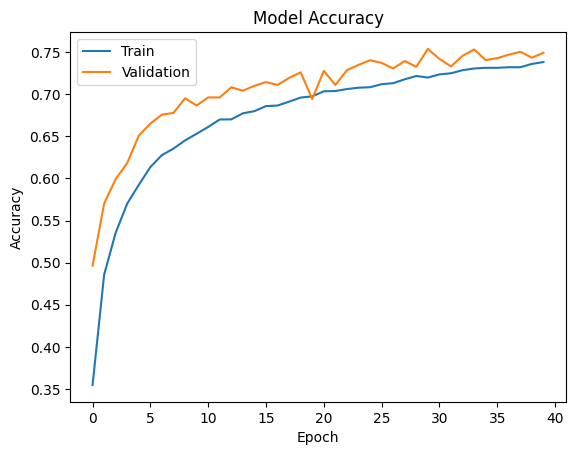

In [15]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [16]:
y_pred=model1.predict(X_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [17]:
print(y_pred.shape)

(5000, 10)


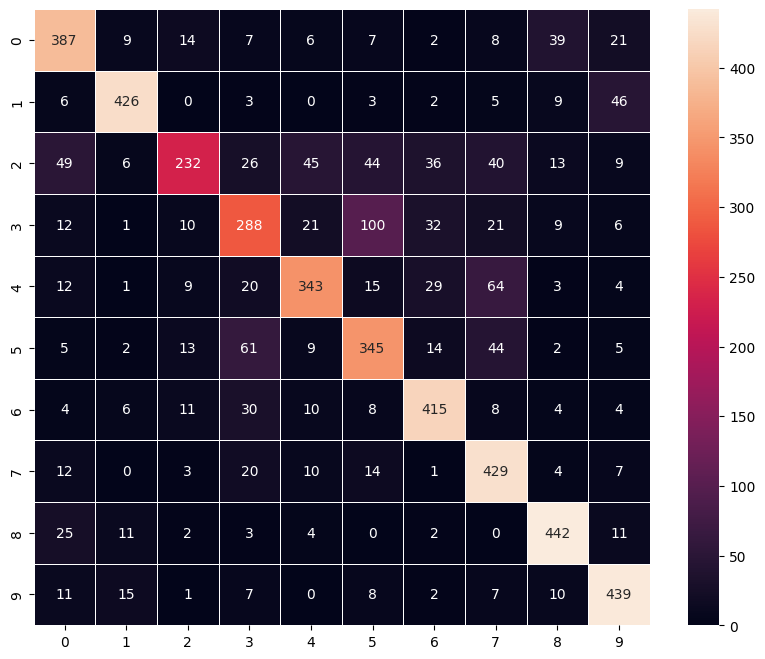

In [18]:
# Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_val, np.argmax(y_pred, axis=1))
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

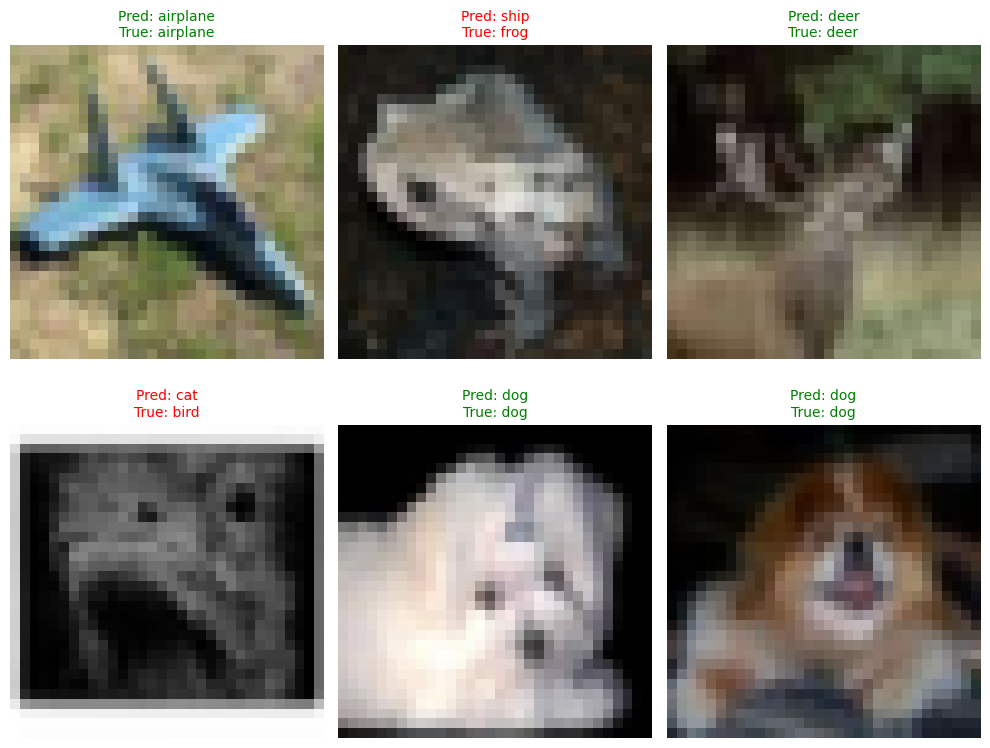

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
for i in range(6):
    idx = 550 + i
    axes[i].imshow(X_val[idx])
    axes[i].axis('off')
    pred_label = (np.argmax(y_pred[idx]))
    true_label = y_val[idx]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}',
                      color=color, fontsize=10)
plt.tight_layout()
plt.show()

##Adding Batch normalization and padding

In [20]:
def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x=layers.Conv2D(filters=32, kernel_size=3, padding="same")(x)
    x=layers.BatchNormalization()(x)
    x=layers.ReLU()(x)
    x=layers.MaxPooling2D(pool_size=2)(x)

    x=layers.Conv2D(filters=64, kernel_size=3, padding="same")(x)
    x=layers.BatchNormalization()(x)
    x=layers.ReLU()(x)
    x=layers.MaxPooling2D(pool_size=2)(x)

    x=layers.Conv2D(filters=128, kernel_size=3, padding="same")(x)
    x=layers.BatchNormalization()(x)
    x=layers.ReLU()(x)
    x=layers.MaxPooling2D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x=layers.Dense(128, activation='relu')(x)
    x=layers.Dropout(0.5)(x)
    x=layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name="custom_cnn")
    return model


In [21]:
model2=build_custom_cnn()
model2.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,322 (1.39 MB)

 Trainable params: 364,874 (1.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
model2=build_custom_cnn(input_shape=(32,32,3), num_classes=10)
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, verbose=1)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.3026 - loss: 1.8394 - val_accuracy: 0.4174 - val_loss: 1.5087
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3939 - loss: 1.6014 - val_accuracy: 0.5220 - val_loss: 1.3242
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4457 - loss: 1.4823 - val_accuracy: 0.5418 - val_loss: 1.3331
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4893 - loss: 1.3813 - val_accuracy: 0.5526 - val_loss: 1.2524
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5214 - loss: 1.3079 - val_accuracy: 0.5862 - val_loss: 1.1948
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5454 - loss: 1.2510 - val_accuracy: 0.6338 - val_loss: 1.0968
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5598 - loss: 1.2060 - val_accuracy: 0.5776 - val_loss: 1.2193
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5833 -

In [23]:
accuracy3 = model2.evaluate(X_train, y_train, verbose=2)
accuracy4 = model2.evaluate(X_val, y_val, verbose=2)

1407/1407 - 6s - 4ms/step - accuracy: 0.7689 - loss: 0.6965
157/157 - 1s - 4ms/step - accuracy: 0.7426 - loss: 0.7553


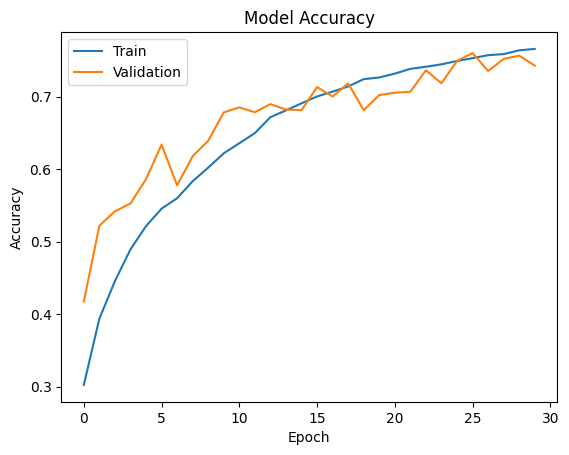

In [24]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [25]:
y_pred1=model2.predict(X_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


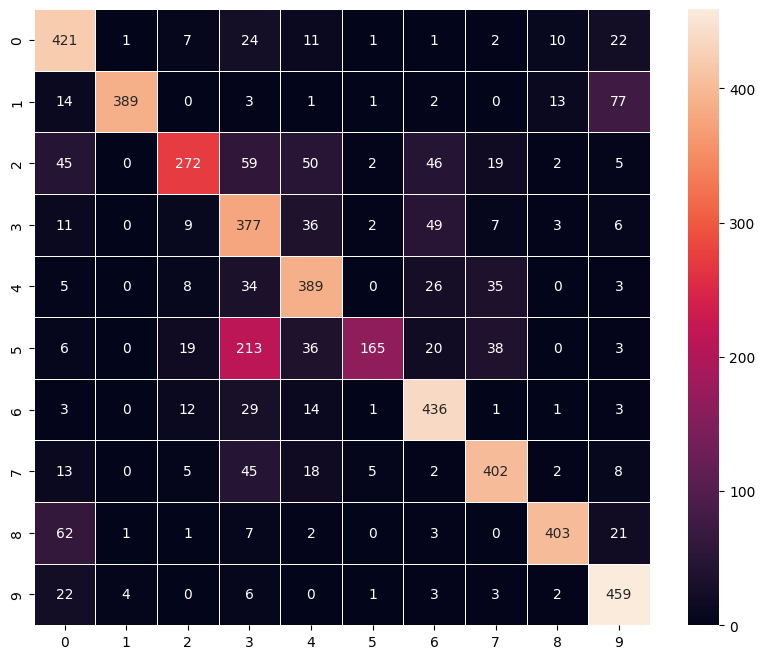

In [26]:
confusion_matrix = tf.math.confusion_matrix(y_val, np.argmax(y_pred1, axis=1))
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

##Visualizing some images between the prediction and the correct label

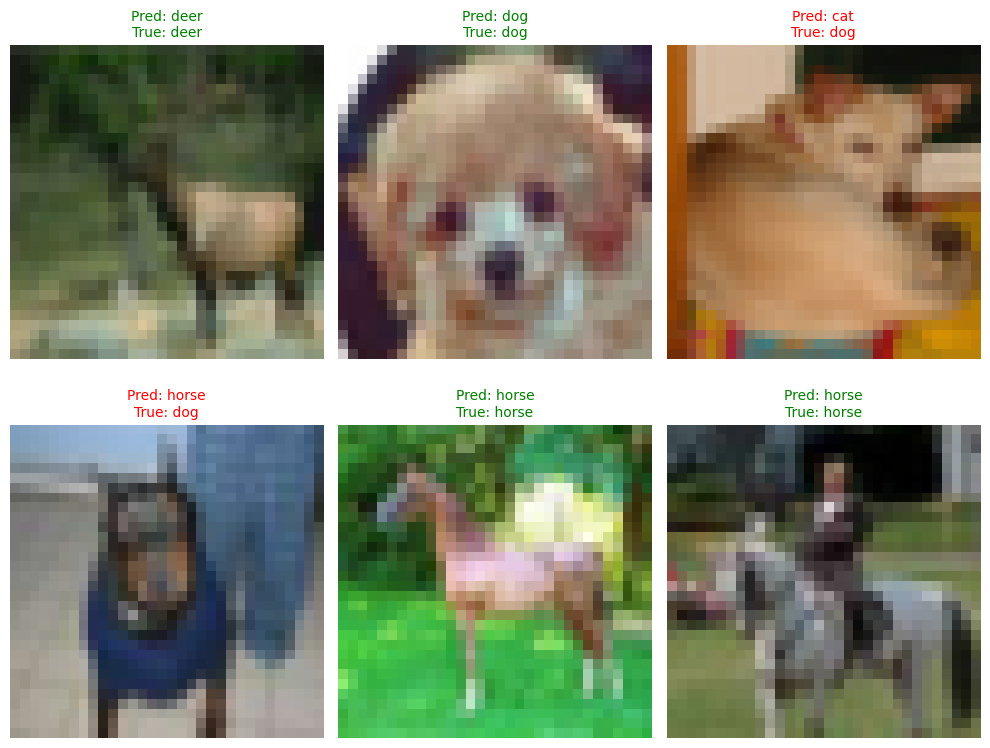

In [27]:
# Visualizing the predicted and correct label of images from test data
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
for i in range(6):
    idx = 500 + i
    axes[i].imshow(X_val[idx])
    axes[i].axis('off')
    pred_label = (np.argmax(y_pred1[idx]))
    true_label = y_val[idx]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}',
                      color=color, fontsize=10)
plt.tight_layout()
plt.show()

In [28]:
model_comparison = pd.DataFrame({
    'Model': ['Model1_CNN', 'Model2_CNN+BN'],
    'Train Accuracy': [accuracy_1[1], accuracy3[1]],
    'Train Loss': [accuracy_2[0], accuracy4[0]],
    'Validation Accuracy': [accuracy_1[1], accuracy3[1]],
    'Validation Loss': [accuracy_2[0], accuracy4[0]]
})
model_comparison

,Model,Train Accuracy,Train Loss,Validation Accuracy,Validation Loss
0,Model1_CNN,0.782133,0.743152,0.782133,0.743152
1,Model2_CNN+BN,0.768911,0.755339,0.768911,0.755339


# Part 3: Transfer Learning Implementation

### This section:  
1. Uses **pre-trained** VGG16.  
2. Extracts features  
3. Experiments with freezing strategies and layer-wise learning rates.  
4. Evaluates compute vs accuracy trade-offs.


## VGG16

In [3]:
from tensorflow.keras.models import Model
from keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.layers import Resizing

In [4]:
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False,
input_shape=(180, 180, 3))

In [31]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.datasets import cifar10

(X_train_full_raw, y_train_full_raw), \
(X_test_vgg_raw, y_test_vgg) = cifar10.load_data()

In [6]:
print(X_train_full_raw.shape)
print(X_test_vgg_raw.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [7]:
y_train_full_raw = y_train_full_raw.squeeze(axis=1)
y_test_vgg = y_test_vgg.squeeze(axis=1)

In [8]:
y_train_full_raw: (50000,)
y_test_vgg:       (10000,)

In [9]:
X_train_vgg_raw, X_val_vgg_raw, y_train_vgg, y_val_vgg = \
    train_test_split(
        X_train_full_raw,
        y_train_full_raw,
        test_size=0.1,
        stratify=y_train_full_raw,
        random_state=SEED
    )

In [10]:
print(X_train_vgg_raw.shape, y_train_vgg.shape)
print(X_val_vgg_raw.shape, y_val_vgg.shape)
print(X_test_vgg_raw.shape, y_test_vgg.shape)

print(X_train_vgg_raw.dtype)
print(X_train_vgg_raw.min(), X_train_vgg_raw.max())

(45000, 32, 32, 3) (45000,)
(5000, 32, 32, 3) (5000,)
(10000, 32, 32, 3) (10000,)
uint8
0 255


In [11]:
assert X_train_vgg_raw.shape[0] == y_train_vgg.shape[0]
assert X_val_vgg_raw.shape[0] == y_val_vgg.shape[0]
assert X_test_vgg_raw.shape[0] == y_test_vgg.shape[0]

In [12]:
train_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (X_train_vgg_raw, y_train_vgg)
)

val_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (X_val_vgg_raw, y_val_vgg)
)

test_dataset_vgg = tf.data.Dataset.from_tensor_slices(
    (X_test_vgg_raw, y_test_vgg)
)

In [13]:
BATCH_SIZE = 64

train_dataset_vgg = (
    train_dataset_vgg
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset_vgg = (
    val_dataset_vgg
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset_vgg = (
    test_dataset_vgg
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

Feature extraction without data augmentation.

In [14]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []

    for images, labels in dataset:
        images = tf.cast(images, tf.float32)

        resized_images = tf.image.resize(
            images,
            size=(180, 180)
        )

        preprocessed_images = (
            keras.applications.vgg16.preprocess_input(
                resized_images
            )
        )

        features = conv_base(
            preprocessed_images,
            training=False
        )

        all_features.append(features.numpy())
        all_labels.append(labels.numpy())

    return (
        np.concatenate(all_features),
        np.concatenate(all_labels)
    )



In [15]:
train_features, train_labels = get_features_and_labels(
    train_dataset_vgg
)

val_features, val_labels = get_features_and_labels(
    val_dataset_vgg
)

In [16]:
inputs = keras.Input(shape=train_features.shape[1:])
x = layers.Flatten()(inputs)
x = layers.Dense(64, activation= "relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)
model_vgg = keras.Model(inputs, outputs)

In [17]:
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [keras.callbacks.ModelCheckpoint(filepath="feature_extraction.keras",
save_best_only=True, monitor="val_loss")]

history3 = model_vgg.fit(train_features, train_labels,
epochs=20,
validation_data=(val_features, val_labels),
callbacks=callbacks, verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.4433 - loss: 1.6507 - val_accuracy: 0.7166 - val_loss: 0.9237
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.5555 - loss: 1.2487 - val_accuracy: 0.7628 - val_loss: 0.7449
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6024 - loss: 1.0860 - val_accuracy: 0.8248 - val_loss: 0.5976
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6357 - loss: 0.9919 - val_accuracy: 0.8466 - val_loss: 0.5341
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6574 - loss: 0.9354 - val_accuracy: 0.8406 - val_loss: 0.5261
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6730 - loss: 0.8958 - val_accuracy: 0.8418 - val_loss: 0.5169
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6874 - loss: 0.8606 - val_accuracy: 0.8504 - val_loss: 0.4956
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6985 - loss: 0.8206 

In [18]:
best_model_vgg = keras.models.load_model(
    "feature_extraction.keras"
)

In [19]:
val_probabilities = model_vgg.predict(
    val_features,
    verbose=0
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

In [20]:
train_loss2, train_accuracy2 = best_model_vgg.evaluate(
    train_features,
    train_labels,
    verbose=2
)

1407/1407 - 7s - 5ms/step - accuracy: 0.9076 - loss: 0.3013


In [21]:
val_loss2, val_accuracy2 = best_model_vgg.evaluate(
    val_features,
    val_labels,
    verbose=2
)

157/157 - 1s - 5ms/step - accuracy: 0.8504 - loss: 0.4956


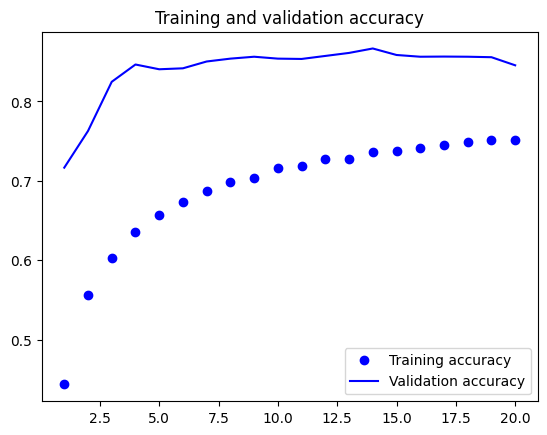

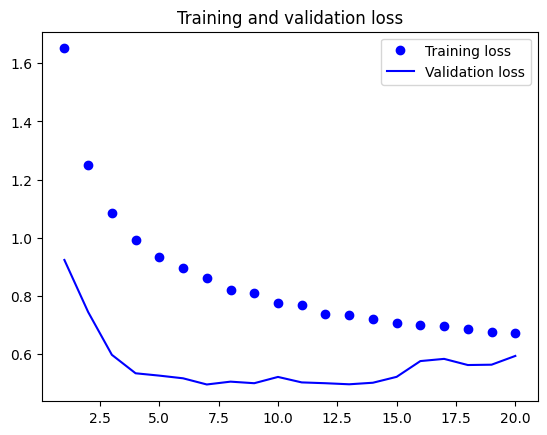

In [22]:
import matplotlib.pyplot as plt
acc = history3.history["accuracy"]
val_acc = history3.history["val_accuracy"]
loss = history3.history["loss"]
val_loss = history3.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

##Feature extraction with data augmentation and freeze


In [ ]:
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False)
conv_base.trainable = False

In [24]:
conv_base.trainable = True
>>> print("This is the number of trainable weights "
"before freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights before freezing the conv base: 26


In [25]:
conv_base.trainable = False
>>> print("This is the number of trainable weights "
"after freezing the conv base:", len(conv_base.trainable_weights))

This is the number of trainable weights after freezing the conv base: 0


In [26]:
data_augmentation_vgg = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
], name="vgg_augmentation")

In [ ]:
inputs = keras.Input(shape=(32,32,3))
x = data_augmentation_vgg(inputs)
x = layers.Resizing(180, 180)(x)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation = "relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model_vgg_frozen = keras.Model(
    inputs,
    outputs,
    name="vgg16_frozen_augmentation"
)
model_vgg_frozen.compile(loss="sparse_categorical_crossentropy",
optimizer="rmsprop",
metrics=["accuracy"])

In [ ]:
callbacks1 = [
keras.callbacks.ModelCheckpoint(
filepath="feature_extraction_with_data_augmentation.keras",
save_best_only=True,
monitor="val_loss")
]

keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history4 = model_vgg_frozen.fit(
    X_train_vgg_raw,
    y_train_vgg,
    validation_data=(X_val_vgg_raw, y_val_vgg), epochs=20, callbacks=callbacks1, verbose=1)

In [ ]:
val_probabilities = model_vgg_frozen.predict(
    X_val_vgg_raw,
    verbose=0
)

val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

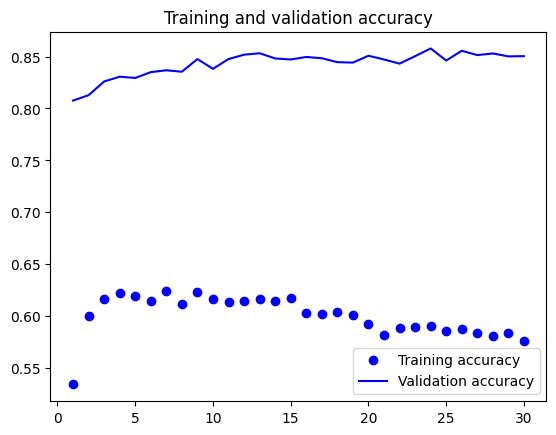

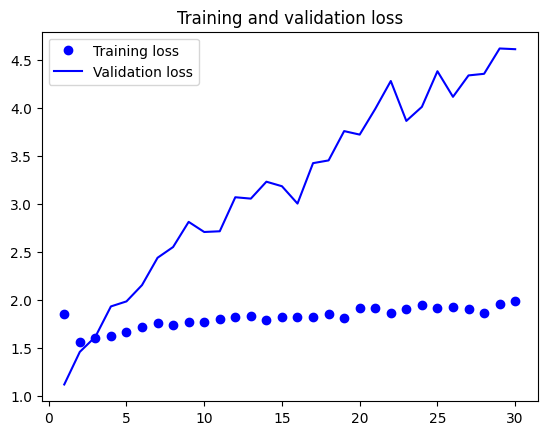

In [ ]:
import matplotlib.pyplot as plt
acc = history4.history["accuracy"]
val_acc = history4.history["val_accuracy"]
loss = history4.history["loss"]
val_loss = history4.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
train_loss3, train_accuracy3 = model_vgg_frozen.evaluate(
    X_train_vgg_raw,
    y_train_vgg,
    batch_size=32,
    verbose=2
)

print(f"Training loss: {train_loss3:.4f}")
print(f"Training accuracy: {train_accuracy3:.4f}")

1407/1407 - 126s - 89ms/step - accuracy: 0.8599 - loss: 3.3546
Training loss: 3.3546
Training accuracy: 0.8599


In [ ]:
val_loss3, val_accuracy3 = model_vgg_frozen.evaluate(
    X_val_vgg_raw,
    y_val_vgg,
    batch_size=32,
    verbose=2
)

print(f"Validation loss: {val_loss3:.4f}")
print(f"Validation accuracy: {val_accuracy3:.4f}")

157/157 - 14s - 92ms/step - accuracy: 0.8504 - loss: 4.6073
Validation loss: 4.6073
Validation accuracy: 0.8504


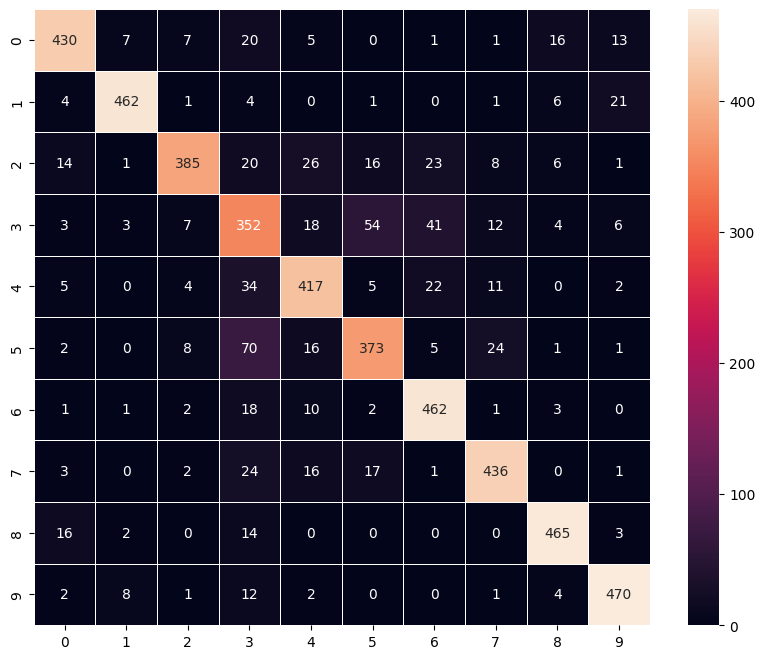

In [ ]:
confusion_matrix = tf.math.confusion_matrix(y_val_vgg, val_predictions)
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


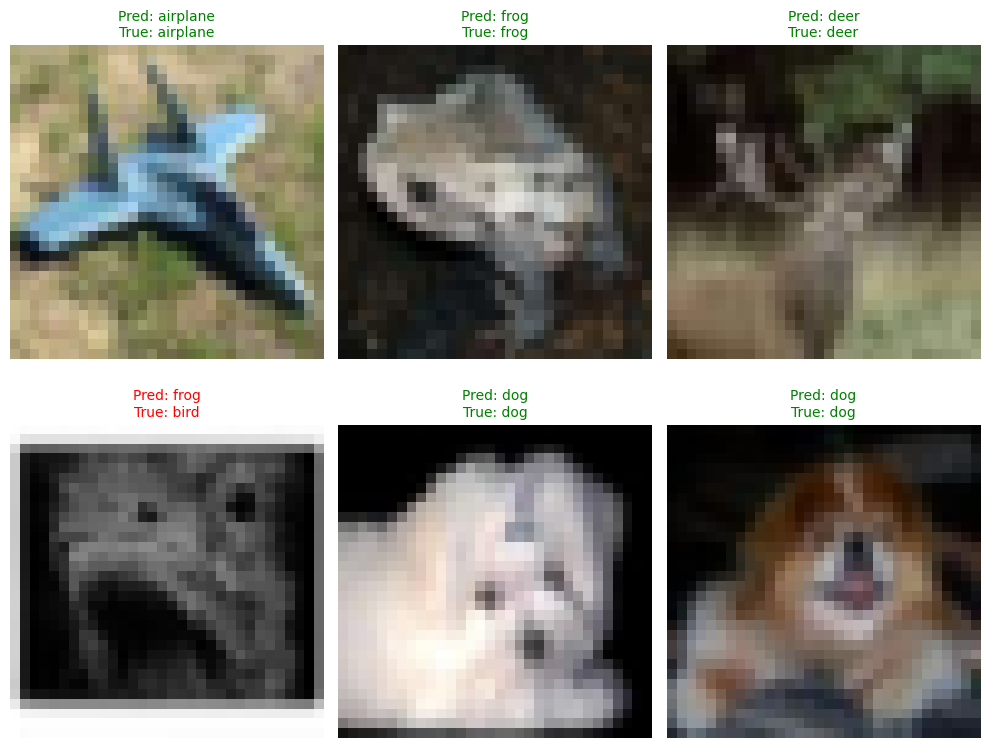

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
for i in range(6):
    idx = 550 + i
    axes[i].imshow(X_val_vgg_raw[idx])
    axes[i].axis('off')
    pred_label = (val_predictions[idx])
    true_label = y_val_vgg[idx]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}',
                      color=color, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
model_comparison_transfer = pd.DataFrame({
    'Model': ['VGG', 'VGG_frozen'],
    'Train Accuracy': [train_accuracy2, train_accuracy3],
    'Train Loss': [train_loss2, train_loss3],
    'Validation Accuracy': [val_accuracy2, val_accuracy3],
    'Validation Loss': [val_loss2, val_loss3]
})
model_comparison_transfer

# Part 3: Advanced CNN Techniques


### This section applies Attention Mechanisms on the CNN+BN model
1. Implements a simple **attention** mechanism (channel or spatial).  
2. Tries with additional regularization (e.g., DropBlock) and stronger augmentation policies.  
3. Experiments with modern optimizers / LR schedules.  
4. Compares loss functions and optional label smoothing.


In [18]:
# ===== ATTENTION MECHANISM =====
def channel_attention(input_feature, ratio=8, name=None):
    """
    Squeeze-and-Excitation (SE) Block
    Applied after convolution layers and before pooling
    """
    channel = input_feature.shape[-1]

    # Squeeze
    squeeze = layers.GlobalAveragePooling2D(name=f'{name}_squeeze' if name else None)(input_feature)

    # Excitation
    excitation = layers.Dense(channel // ratio, activation='relu',
                             name=f'{name}_fc1' if name else None)(squeeze)
    excitation = layers.Dense(channel, activation='sigmoid',
                             name=f'{name}_fc2' if name else None)(excitation)
    excitation = layers.Reshape((1, 1, channel),
                               name=f'{name}_reshape' if name else None)(excitation)

    # Scale: Multiply input by attention weights
    return layers.Multiply(name=f'{name}_multiply' if name else None)([input_feature, excitation])

# DROPBLOCK REGULARIZATION
class DropBlock2D(layers.Layer):
    """
    DropBlock: drops contiguous regions instead of random pixels
    Applied after pooling in convolution blocks
    Sometimes it is more effective than dropout
    """
    def __init__(self, block_size=7, drop_prob=0.1, **kwargs):
        super(DropBlock2D, self).__init__(**kwargs)
        self.block_size = block_size
        self.drop_prob = drop_prob

    def call(self, inputs, training=None):
        if not training or self.drop_prob == 0:
            return inputs

        # Calculate gamma
        feat_size = tf.cast(tf.shape(inputs)[1], tf.float32)
        gamma = (self.drop_prob * feat_size**2 /
                 self.block_size**2 /
                 (feat_size - self.block_size + 1)**2)

        # Sample Bernoulli mask
        mask_shape = [tf.shape(inputs)[0],
                     tf.shape(inputs)[1],
                     tf.shape(inputs)[2],
                     tf.shape(inputs)[3]]
        mask = tf.random.uniform(mask_shape) >= gamma
        mask = tf.cast(mask, tf.float32)

        # Expand mask to block size
        block_mask = tf.nn.max_pool2d(mask,
                                       ksize=self.block_size,
                                       strides=1,
                                       padding='SAME')

        # Normalize to maintain expected value
        count = tf.reduce_sum(block_mask)
        count_all = tf.cast(tf.reduce_prod(mask_shape), tf.float32)
        normalize_factor = count_all / (count + 1e-7)

        return inputs * block_mask * normalize_factor

    def get_config(self):
        config = super().get_config()
        config.update({
            'block_size': self.block_size,
            'drop_prob': self.drop_prob
        })
        return config

In [19]:
def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

  #Convolution layers
    x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Attention layer
    x = channel_attention(x, ratio=4, name='attention_block1')
    x = layers.MaxPooling2D(pool_size=2)(x)

    # DropBlock layer
    x = DropBlock2D(block_size=5, drop_prob=0.1)(x)

    # CONVOLUTION BLOCK
    x = layers.Conv2D(64, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Attention layer
    x = channel_attention(x, ratio=8, name='attention_block2')
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Dropblock layer
    x = DropBlock2D(block_size=5, drop_prob=0.1)(x)

    # CONVOLUTION LAYER
    x = layers.Conv2D(128, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, kernel_size=3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # ATTENTION LAYER
    x = channel_attention(x, ratio=16, name='attention_block3')

    x = layers.MaxPooling2D(pool_size=2)(x)

    # DENSE LAYERS
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)  # Regular Dropout for dense layers
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="custom_cnn_with_attention")
    return model

In [24]:
model5 = build_custom_cnn()

model5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_model5 = [
    keras.callbacks.ModelCheckpoint(
        filepath="custom_cnn_with_attention_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True
    )
]

# Train
history5 = model5.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=callbacks_model5)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 266s 358ms/step - accuracy: 0.2924 - loss: 1.8852 - val_accuracy: 0.3852 - val_loss: 1.7015
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 256s 364ms/step - accuracy: 0.4030 - loss: 1.5949 - val_accuracy: 0.5484 - val_loss: 1.3588
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 253s 359ms/step - accuracy: 0.4687 - loss: 1.4618 - val_accuracy: 0.5306 - val_loss: 1.3523
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 258s 366ms/step - accuracy: 0.5169 - loss: 1.3536 - val_accuracy: 0.6306 - val_loss: 1.0963
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 362ms/step - accuracy: 0.5513 - loss: 1.2714 - val_accuracy: 0.6300 - val_loss: 1.1122
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 365ms/step - accuracy: 0.5844 - loss: 1.1898 - val_accuracy: 0.6768 - val_loss: 0.9624
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 251s 357ms/step - accuracy: 0.6126 - loss: 1.1163 - val_accuracy: 0.6770 - val_loss: 0.9531
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 369ms/step - accuracy: 0.6378 -

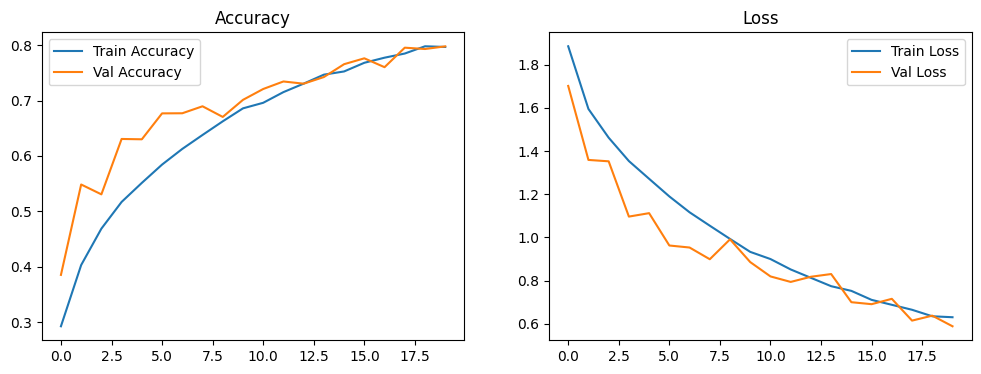

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history5.history['accuracy'], label='Train Accuracy')
plt.plot(history5.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history5.history['loss'], label='Train Loss')
plt.plot(history5.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [26]:
y_pred5=model5.predict(X_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step


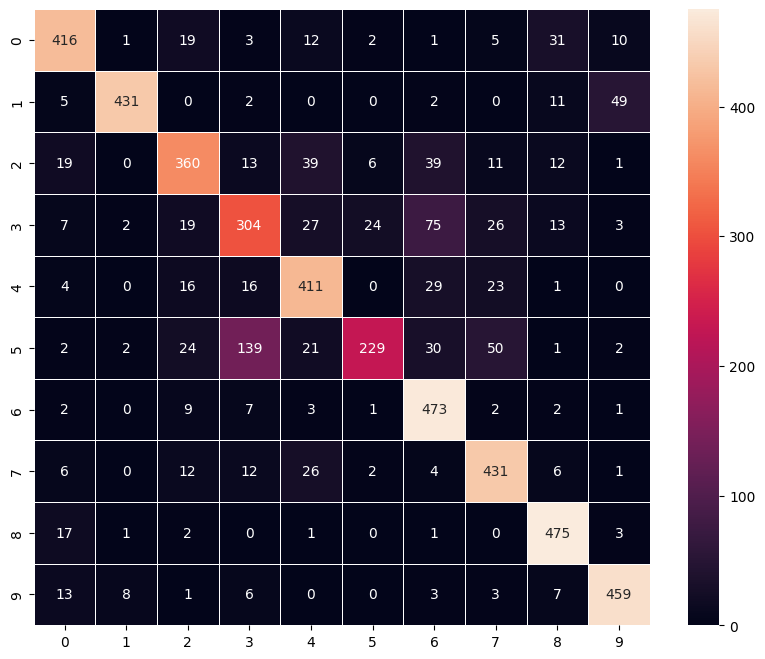

In [27]:
confusion_matrix = tf.math.confusion_matrix(y_val, np.argmax(y_pred5, axis=1))
f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

In [37]:
# Evaluate
val_loss, val_acc = model5.evaluate(X_val, y_val, verbose=0)
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation loss: {val_loss:.4f}")

Validation accuracy: 0.7978
Validation loss: 0.5883


In [38]:
train_loss, train_acc = model5.evaluate(X_train, y_train, verbose=0)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Train loss: {train_loss:.4f}")

Train accuracy: 0.8186
Train loss: 0.5319


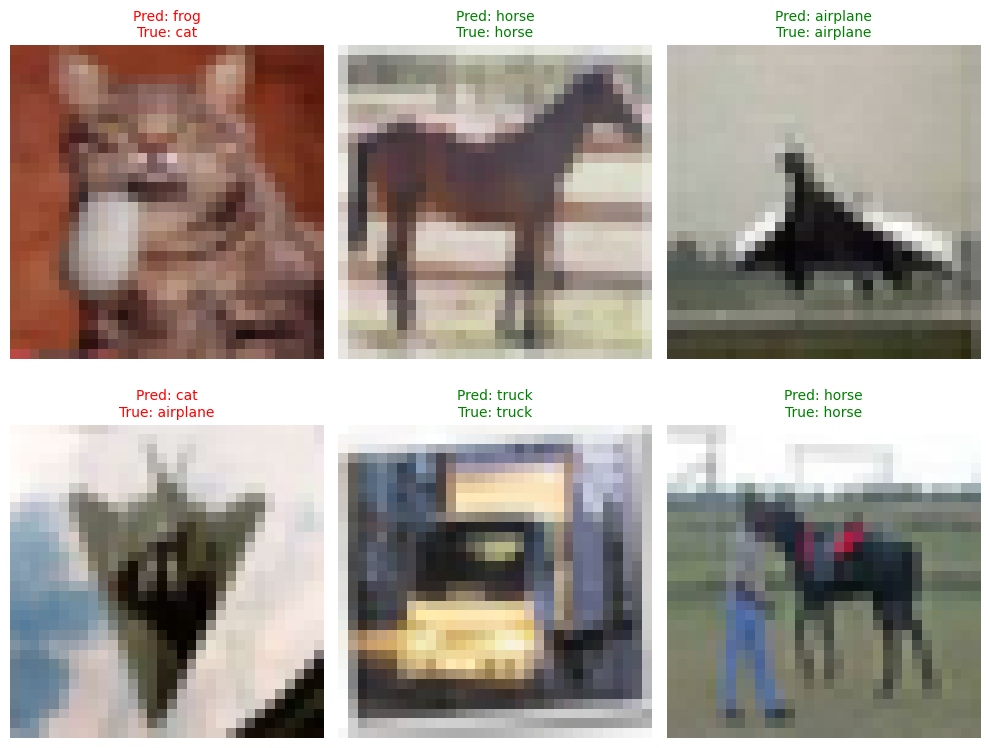

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()
for i in range(6):
    idx = 390 + i
    axes[i].imshow(X_val[idx])
    axes[i].axis('off')
    pred_label = np.argmax(y_pred5[idx])
    true_label = y_val[idx]
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}',
                      color=color, fontsize=10)
plt.tight_layout()
plt.show()

In [31]:
sched = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=1000
)

In [32]:
opt = keras.optimizers.Adam(
    learning_rate=sched
)

In [33]:
opt = keras.optimizers.Adam(
    learning_rate=sched
)

In [34]:
model_attention = build_custom_cnn()
model_attention.compile(
    optimizer=opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [35]:
callbacks_model6 = [
    keras.callbacks.ModelCheckpoint(
        filepath="cnn_attention_LR_best.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True
    )
]

In [36]:
history6 = model_attention.fit(
    X_train, y_train,
    batch_size=64,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks_model6
    )

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 361ms/step - accuracy: 0.3201 - loss: 1.8167 - val_accuracy: 0.4972 - val_loss: 1.4047
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 278s 395ms/step - accuracy: 0.4198 - loss: 1.5596 - val_accuracy: 0.4970 - val_loss: 1.4027
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 300s 364ms/step - accuracy: 0.4949 - loss: 1.3923 - val_accuracy: 0.5584 - val_loss: 1.1655
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 363ms/step - accuracy: 0.5606 - loss: 1.2206 - val_accuracy: 0.6762 - val_loss: 0.9452
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 251s 356ms/step - accuracy: 0.5527 - loss: 1.2539 - val_accuracy: 0.5854 - val_loss: 1.2331
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 350ms/step - accuracy: 0.5847 - loss: 1.1853 - val_accuracy: 0.6140 - val_loss: 1.0987
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 248s 353ms/step - accuracy: 0.6248 - loss: 1.0782 - val_accuracy: 0.6958 - val_loss: 0.8869
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 252s 358ms/step - accuracy: 0.6575 -

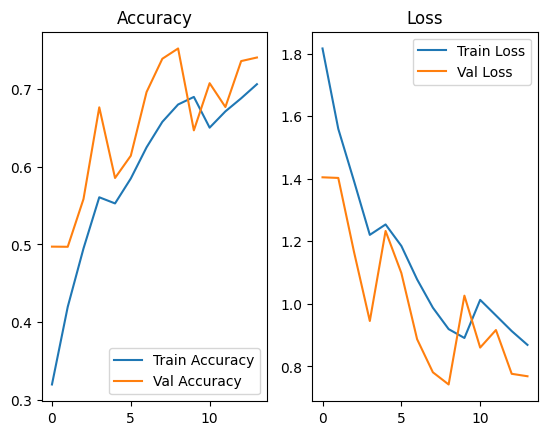

In [39]:
plt.subplot(1, 2, 1)
plt.plot(history6.history['accuracy'], label='Train Accuracy')
plt.plot(history6.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history6.history['loss'], label='Train Loss')
plt.plot(history6.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [40]:
y_pred6=model_attention.predict(X_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step


In [41]:
val_loss1, val_acc1 = model_attention.evaluate(X_val, y_val, verbose=0)
print(f"Validation accuracy: {val_acc1:.4f}")
print(f"Validation loss: {val_loss1:.4f}")

Validation accuracy: 0.7518
Validation loss: 0.7422


In [42]:
train_loss1, train_acc1 = model_attention.evaluate(X_train, y_train, verbose=0)
print(f"Train accuracy: {train_acc1:.4f}")
print(f"Train loss: {train_loss1:.4f}")

Train accuracy: 0.7651
Train loss: 0.7158


In [43]:
test_loss1, test_acc1 = model_attention.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc1:.4f}")
print(f"Test loss: {test_loss1:.4f}")

Test accuracy: 0.7468
Test loss: 0.7595


In [ ]:
model_comparison_attention = pd.DataFrame({
    'Model': ['CNN', 'CNN+BN', "CNN+BN+Attention", "CNN+BN+Attention+LR_schedule"],
    'Train Accuracy': [accuracy_1[1], accuracy3[1], train_acc, train_acc1],
    'Train Loss': [accuracy_2[0], accuracy4[0], train_loss, train_loss1],
    'Validation Accuracy': [accuracy_1[1], accuracy3[1], val_acc, val_acc1],
    'Validation Loss': [accuracy_2[0], accuracy4[0], val_loss, val_loss1]
})
model_comparison_attention

# Conclusions



This project investigated several deep-learning approaches for classifying
CIFAR-10 images. The experiments progressed from a baseline convolutional
neural network to architectures using batch normalization, VGG16 transfer
learning, Squeeze-and-Excitation channel attention, DropBlock regularization,
and a cosine-decay learning-rate schedule.

The baseline CNN established a validation accuracy of approximately 74.9%.
Adding batch normalization and same padding improved the best validation
accuracy to approximately 76.7%, although the improvement was smaller than
expected. This demonstrates that adding architectural components does not
automatically improve performance and that their effectiveness depends on
the complete training configuration.

VGG16 feature extraction produced a substantial improvement over the simpler
CNN models. Its checkpoint selected by validation loss reached 85.0%
validation accuracy with a validation loss of 0.496. This suggests that
features learned from ImageNet can transfer effectively to CIFAR-10, even
though CIFAR-10 images are much smaller and belong to a different image
distribution.

The frozen VGG16 experiment reached high classification accuracy during some
epochs, but its validation loss increased considerably. This means that the
model made many correct predictions while becoming excessively confident
about some incorrect predictions. Consequently, accuracy alone was not
sufficient for evaluating this model. A smaller learning rate, early stopping,
global average pooling, and stronger control of the dense classification head
would be appropriate improvements.

The custom CNN with Squeeze-and-Excitation attention achieved 84.6% validation
accuracy. When combined with a cosine-decay learning-rate schedule, it reached
the strongest observed validation result: 86.7% accuracy and 0.399.

Overall, the experiments show that both transfer learning and channel
attention can improve CIFAR-10 classification. The attention-based CNN is an
especially promising candidate because it achieved competitive performance
without requiring the computationally expensive resizing and VGG16 feature
extractor.